In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import seaborn as sns
import requests
import json
from scipy.stats import pearsonr, spearmanr

# 나눔바른고딕 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 한글 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

# 그래프 한글 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

In [43]:
import pandas as pd

file_charging = '한국환경공단_전기차 충전소 위치 및 운영정보_20221027.csv'
file_reg = '서울시 자치구별 연료별 차종별 용도별 등록현황(25년07월).xlsx'

# 충전소 데이터 읽기
df_stations = pd.read_csv(file_charging, encoding='cp949')

# 서울시만 추출
df_seoul_stations = df_stations[
    df_stations['시도'] == '서울특별시'
].copy()

# 구별 충전기 수 집계
charger_counts = (df_seoul_stations.groupby('군구').size().reset_index(name='충전기수'))

charger_counts.columns = ['자치구', '충전기수']

charger_counts.head(10)

,자치구,충전기수
0,강남구,2641
1,강동구,1352
2,강북구,633
3,강서구,1976
4,관악구,698
5,광진구,638
6,구로구,1634
7,금천구,1098
8,노원구,1520
9,도봉구,801


In [44]:
# [2] 자동차 등록 데이터 처리

# 엑셀 읽기
df_reg_raw = pd.read_excel(
    file_reg,
    skiprows=6
)

# 필요한 열만 선택
df_reg_raw = df_reg_raw.iloc[:, [0, 3, 15]]

# 컬럼명 변경
df_reg_raw.columns = ['자치구', '연료별', '총계']

# 자치구 결측치 채우기
df_reg_raw['자치구'] = (
    df_reg_raw['자치구']
    .replace('', np.nan)
    .ffill()
)

# 합계 제거
df_reg_raw = df_reg_raw[
    df_reg_raw['자치구'] != '합 계'
]

# 숫자형 변환
df_reg_raw['총계'] = pd.to_numeric(
    df_reg_raw['총계'],
    errors='coerce'
)

df_reg_raw.head(20)

,자치구,연료별,총계
1,종로구,CNG,20
2,종로구,CNG,69
3,종로구,경유,14520
4,종로구,경유,1396
5,종로구,기타연료,126
6,종로구,기타연료,128
7,종로구,수소,87
8,종로구,수소전기,7
9,종로구,엘피지,1708
10,종로구,엘피지,371


In [45]:
dist_total = (
    df_reg_raw
    .groupby('자치구')['총계']
    .sum()
    .reset_index(name='전체차량대수')
)

ev_reg = (
    df_reg_raw[df_reg_raw['연료별'] == '전기']
    .groupby('자치구')['총계']
    .sum()
    .reset_index(name='전기차등록대수')
)

ev_reg.head(5)

,자치구,전기차등록대수
0,강남구,14485
1,강동구,4626
2,강북구,1578
3,강서구,4881
4,관악구,2421


In [46]:
#데이터프레임 병합

df_final = pd.merge(
    dist_total,
    ev_reg,
    on='자치구'
)

df_final = pd.merge(
    df_final,
    charger_counts,
    on='자치구'
)

df_final.head(5)

,자치구,전체차량대수,전기차등록대수,충전기수
0,강남구,253031,14485,2641
1,강동구,168994,4626,1352
2,강북구,73005,1578,633
3,강서구,201567,4881,1976
4,관악구,116462,2421,698


In [47]:
#핵심 변수 생성
df_final['전기차보급률'] = (
    df_final['전기차등록대수']
    / df_final['전체차량대수']
)

# 충전소 밀도
df_final['충전기밀도'] = (
    df_final['충전기수']
    / df_final['전체차량대수']
)

# 퍼센트 보기 좋게 변환
df_final['전기차보급률(%)'] = (
    df_final['전기차보급률'] * 100
)

df_final['충전기밀도(%)'] = (
    df_final['충전기밀도'] * 100
)

# 정렬
df_final = (
    df_final
    .sort_values(by='자치구')
    .reset_index(drop=True)
)

# 인덱스 1부터
df_final.index = df_final.index + 1

display(df_final.head(5))

,자치구,전체차량대수,전기차등록대수,충전기수,전기차보급률,충전기밀도,전기차보급률(%),충전기밀도(%)
1,강남구,253031,14485,2641,0.057246,0.010437,5.724595,1.043746
2,강동구,168994,4626,1352,0.027374,0.008000,2.737375,0.800028
3,강북구,73005,1578,633,0.021615,0.008671,2.161496,0.867064
4,강서구,201567,4881,1976,0.024215,0.009803,2.421527,0.980319
5,관악구,116462,2421,698,0.020788,0.005993,2.078790,0.599337


In [48]:
#기초통계 확인
print(df_final.describe())

              전체차량대수       전기차등록대수         충전기수     전기차보급률      충전기밀도  \
count      25.000000     25.000000    25.000000  25.000000  25.000000   
mean   126706.680000   3663.040000  1358.120000   0.027775   0.011147   
std     51891.354256   2714.496769   567.003624   0.008977   0.003428   
min     49823.000000   1578.000000   633.000000   0.020019   0.005993   
25%     93639.000000   2227.000000   905.000000   0.022039   0.009516   
50%    116462.000000   2848.000000  1328.000000   0.024215   0.010123   
75%    149543.000000   3592.000000  1634.000000   0.030699   0.012351   
max    253031.000000  14485.000000  2641.000000   0.057246   0.019612   

       전기차보급률(%)   충전기밀도(%)  
count  25.000000  25.000000  
mean    2.777450   1.114707  
std     0.897746   0.342787  
min     2.001889   0.599337  
25%     2.203935   0.951559  
50%     2.421527   1.012328  
75%     3.069946   1.235124  
max     5.724595   1.961175  


/tmp/ipykernel_16147/1132725819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_final.sort_values(by='충전기밀도',ascending=False),


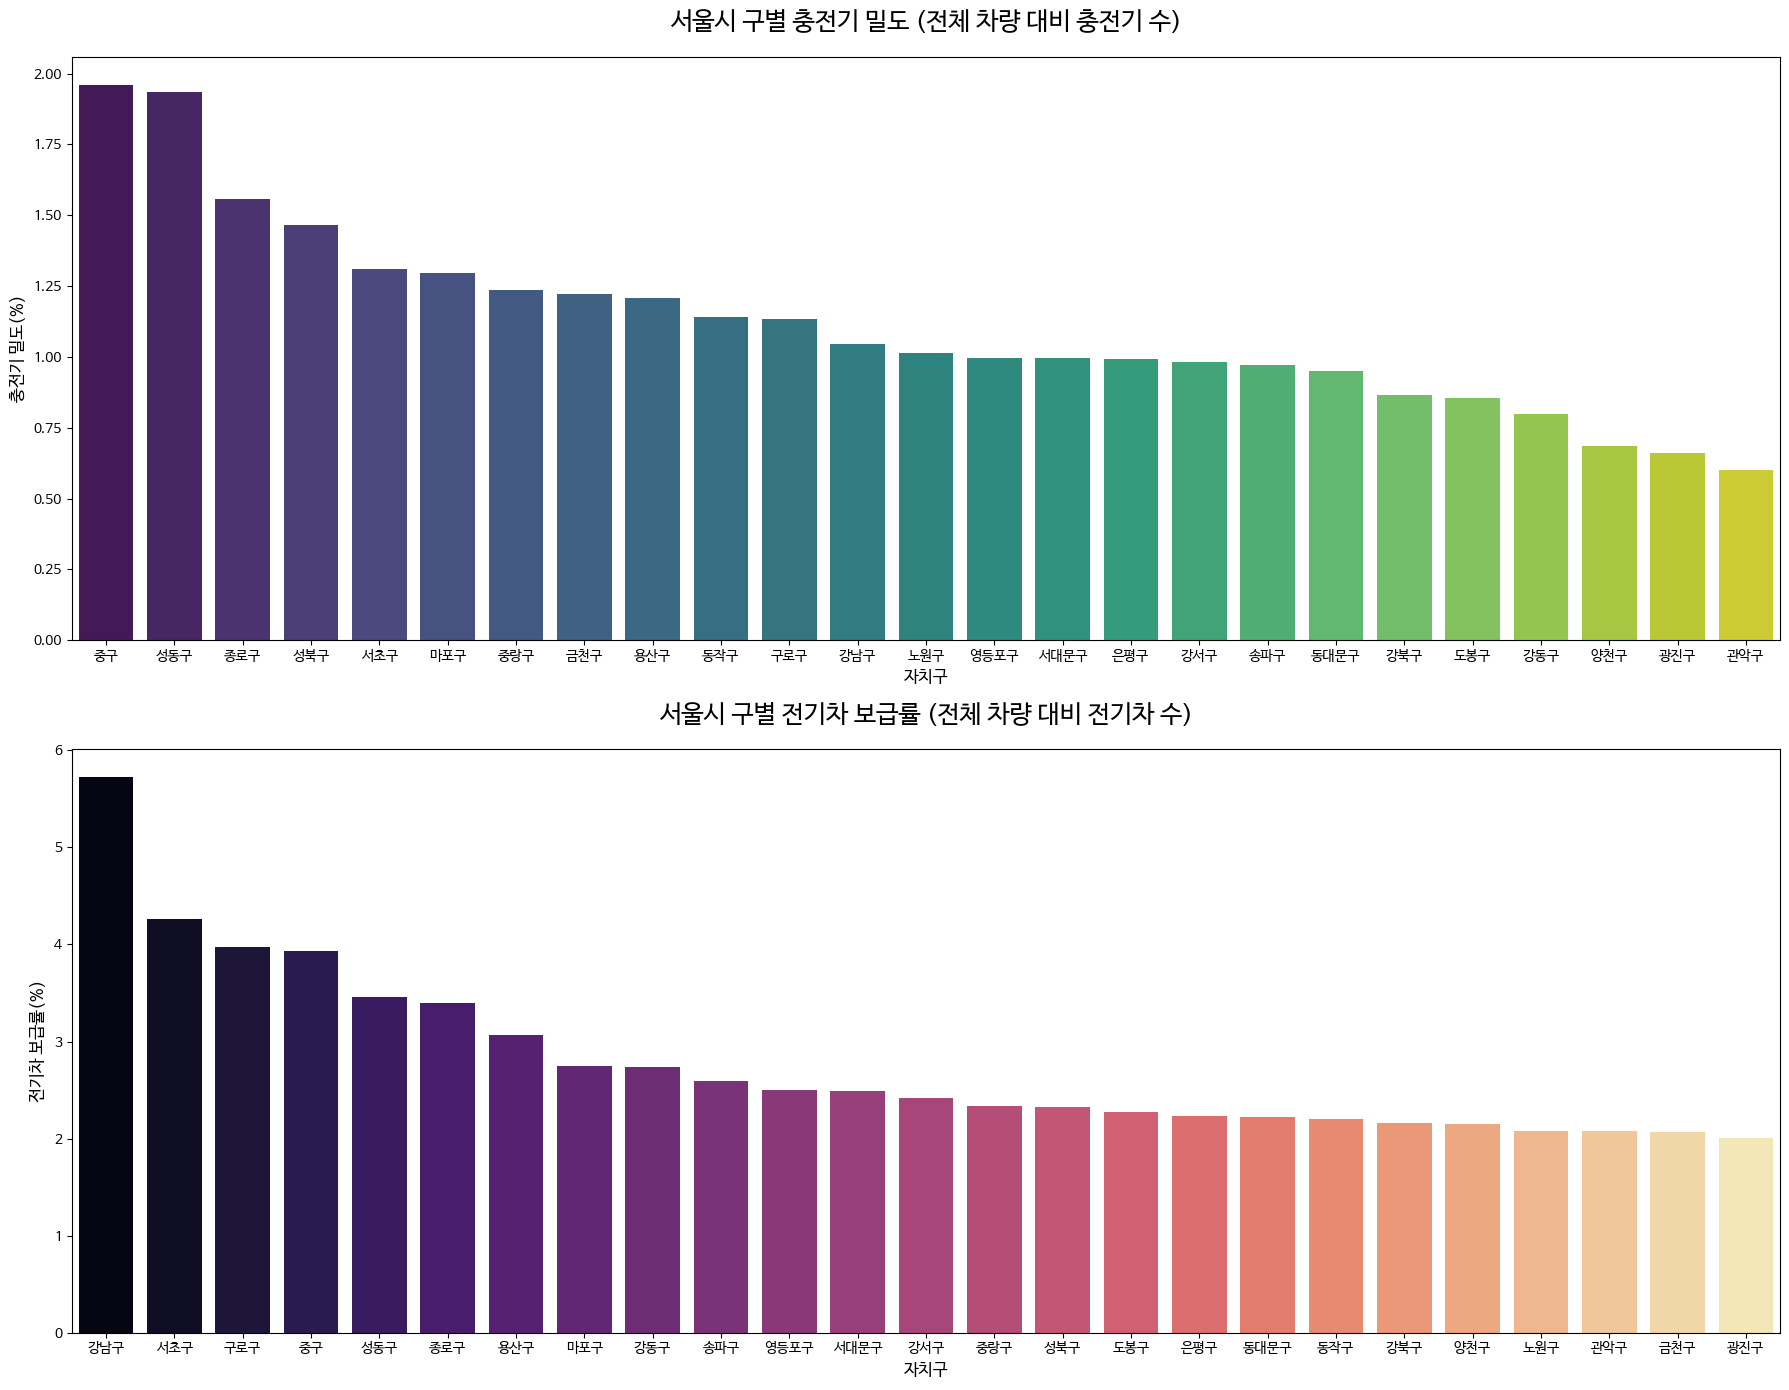

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(18, 14))
#충전소 밀도 시각화
sns.barplot(data=df_final.sort_values(by='충전기밀도',ascending=False),
    x='자치구',y='충전기밀도(%)', ax=axes[0], palette='viridis'
)

axes[0].set_title('서울시 구별 충전기 밀도 (전체 차량 대비 충전기 수)', fontsize=18, pad=20)
axes[0].set_xlabel('자치구', fontsize=12)
axes[0].set_ylabel('충전기 밀도(%)', fontsize=12)


#전기차 보급률 시각화
sns.barplot(data=df_final.sort_values(by='전기차보급률',ascending=False ),
    x='자치구', y='전기차보급률(%)',ax=axes[1], palette='magma',hue='자치구',legend=False)

axes[1].set_title('서울시 구별 전기차 보급률 (전체 차량 대비 전기차 수)', fontsize=18, pad=20)
axes[1].set_xlabel('자치구', fontsize=12)
axes[1].set_ylabel('전기차 보급률(%)', fontsize=12)

plt.tight_layout()
plt.show()

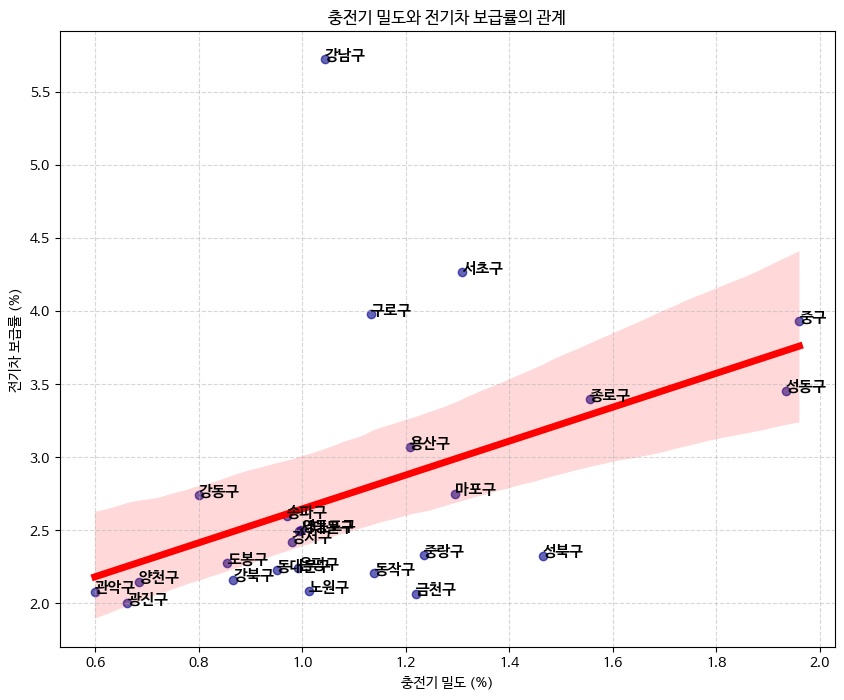

In [50]:
# 산점도 + 회귀선
plt.figure(figsize=(10,8))

sns.regplot(data=df_final, x='충전기밀도(%)', y='전기차보급률(%)',
            scatter_kws={'alpha': 0.6, 'color':'darkblue'},
            line_kws={'color': 'red', 'lw': 5}
)

# 구 이름 표시
for i in range(len(df_final)):

    plt.text(
        df_final['충전기밀도(%)'].iloc[i],
        df_final['전기차보급률(%)'].iloc[i],
        df_final['자치구'].iloc[i], fontsize=11, weight='bold'
    )

plt.title('충전기 밀도와 전기차 보급률의 관계')
plt.grid(True, linestyle='--',alpha=0.5)
plt.xlabel('충전기 밀도 (%)')
plt.ylabel('전기차 보급률 (%)')

plt.show()

In [51]:
#피어슨 상관계수
pearson_corr, pearson_p = pearsonr(
    df_final['충전기밀도'],
    df_final['전기차보급률']
)

print('\n[피어슨 상관분석]')
print('상관계수:', round(pearson_corr, 4))
print('p-value:', round(pearson_p, 4))


[피어슨 상관분석]
상관계수: 0.4426
p-value: 0.0267


In [52]:
#스피어만 상관계수
spearman_corr, spearman_p = spearmanr(
    df_final['충전기밀도'],
    df_final['전기차보급률']
)

print('\n[스피어만 상관분석]')
print('상관계수:', round(spearman_corr, 4))
print('p-value:', round(spearman_p, 4))


[스피어만 상관분석]
상관계수: 0.5692
p-value: 0.003


In [53]:
#회귀분석
from sklearn.linear_model import LinearRegression

X = df_final[['충전기밀도']]
y = df_final['전기차보급률']

model = LinearRegression()

model.fit(X, y)

print('\n[회귀분석 결과]')
print('회귀계수:', model.coef_[0])
print('절편:', model.intercept_)
print('R^2:', model.score(X, y))


[회귀분석 결과]
회귀계수: 1.1592213407430234
절편: 0.014852581312565094
R^2: 0.19591818352890378


In [54]:
import folium
import requests

# 1. 서울시 행정구역 GeoJSON 로드 (구 단위)
geo_url = 'https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json'
geo_json = requests.get(geo_url).json()

# 2. 색상 구간(Bins)을 데이터의 분위수(Quantile)로 설정
bins = list(df_final['전기차보급률'].quantile([0, 0.25, 0.5, 0.75, 1]))

# 3. 지도 생성 (서울 시청 중심)
m = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='cartodbpositron')

# 4. 단계구분도(Choropleth) 레이어 추가
folium.Choropleth(
    geo_data=geo_json,
    data=df_final,
    columns=['자치구', '전기차보급률'],
    key_on='feature.properties.name',
    fill_color='YlOrRd', # 노랑->주황->빨강
    fill_opacity=0.7,
    line_opacity=0.3,
    bins=bins,           # 설정한 구간 적용
    legend_name='구별 전기차 보급률 (데이터 구간별)'
).add_to(m)

# 5. 각 구의 중심에 이름표(Tooltip) 달기 (마우스를 올리면 이름이 떠요)
folium.GeoJson(
    geo_json,

    style_function=lambda x: {
        'fillColor': 'transparent',
        'color': 'transparent',
        'weight': 0
    },

    tooltip=folium.GeoJsonTooltip(
        fields=['name'],
        aliases=['자치구:'],
        localize=True
    )

).add_to(m)

m

In [56]:
#결과 해석
print('\n[가설검증 결과 해석]')

if pearson_p < 0.05:

    print('충전기 밀도와 전기차 보급률 사이에 통계적으로 유의한 상관관계가 존재합니다.')

else:

    print('통계적으로 유의한 상관관계가 있다고 보기 어렵습니다.')


[가설검증 결과 해석]
충전기 밀도와 전기차 보급률 사이에 통계적으로 유의한 상관관계가 존재합니다.


# 강남구 제외 상관관계 분석

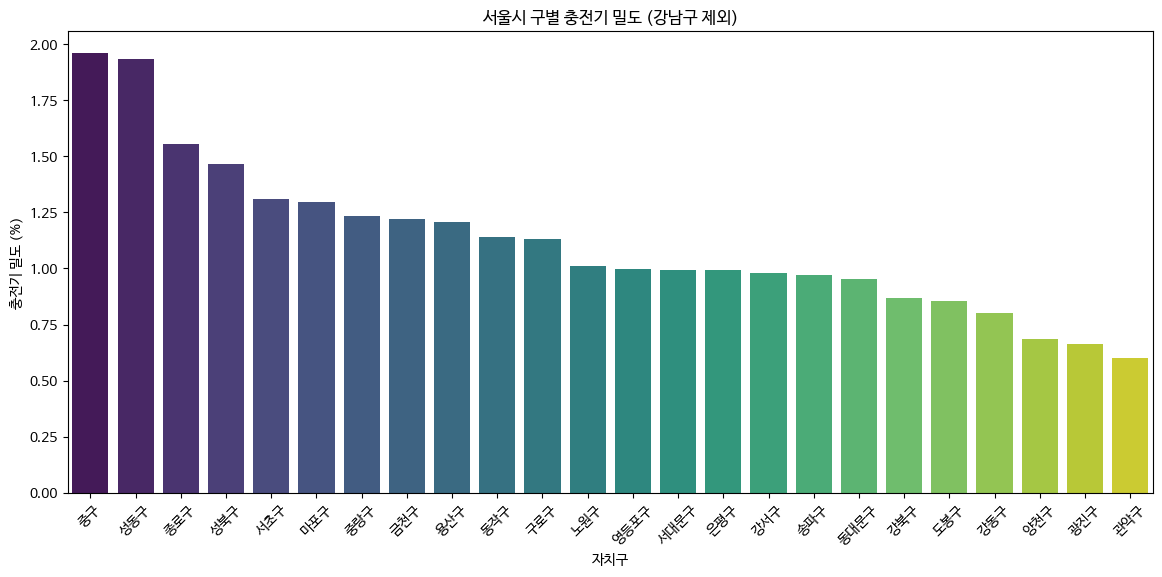

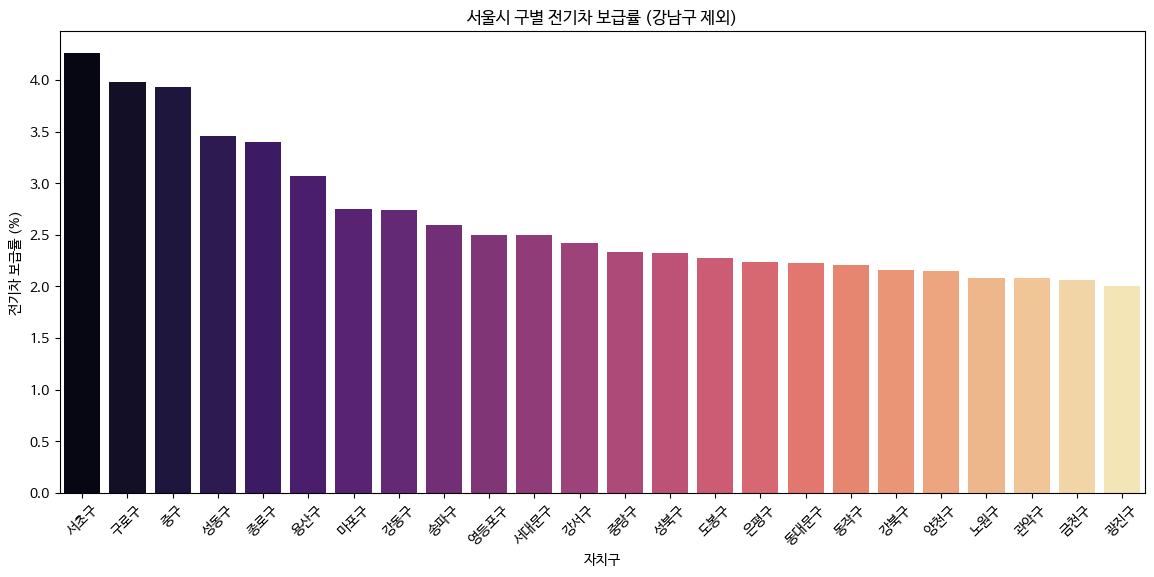

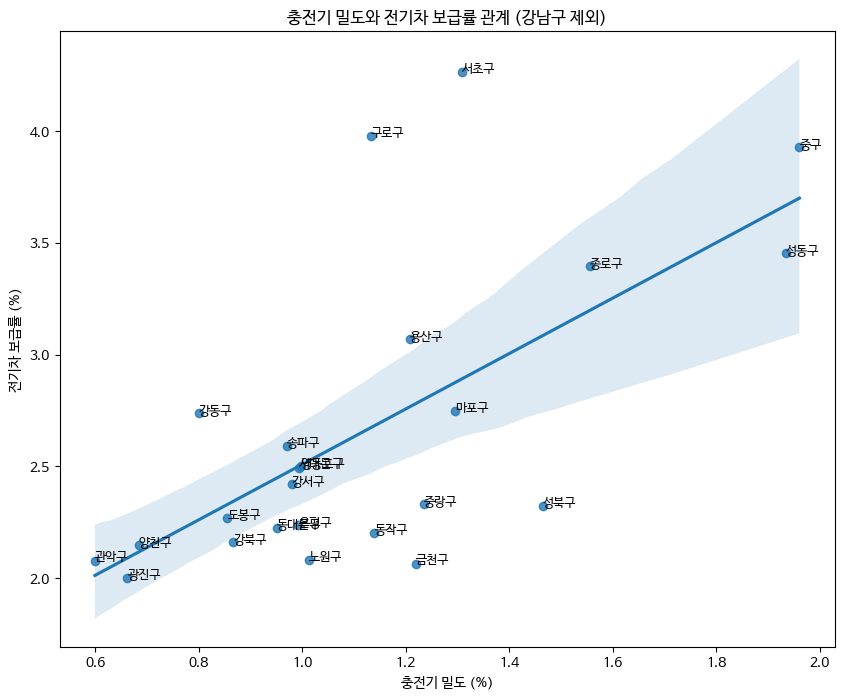


[강남구 제외 후 상관분석 결과]

피어슨 상관계수
상관계수: 0.6477
p-value: 0.0006

스피어만 상관계수
상관계수: 0.5965
p-value: 0.0021


In [57]:
# =========================
# 강남구 제외 데이터 생성
# =========================

df_no_gangnam = df_final[
    df_final['자치구'] != '강남구'
].copy()


# =========================================================
# [1] 충전소 밀도 시각화
# =========================================================

plt.figure(figsize=(14,6))

sns.barplot(
    data=df_no_gangnam.sort_values(
        by='충전기밀도',
        ascending=False
    ),
    x='자치구',
    y='충전기밀도(%)',
    palette='viridis',
    hue='자치구',
    legend=False
)

plt.xticks(rotation=45)

plt.title('서울시 구별 충전기 밀도 (강남구 제외)')

plt.xlabel('자치구')
plt.ylabel('충전기 밀도 (%)')

plt.show()


# =========================================================
# [2] 전기차 보급률 시각화
# =========================================================

plt.figure(figsize=(14,6))

sns.barplot(
    data=df_no_gangnam.sort_values(
        by='전기차보급률',
        ascending=False
    ),
    x='자치구',
    y='전기차보급률(%)',
    palette='magma',
    hue='자치구',
    legend=False
)

plt.xticks(rotation=45)

plt.title('서울시 구별 전기차 보급률 (강남구 제외)')

plt.xlabel('자치구')
plt.ylabel('전기차 보급률 (%)')

plt.show()


# =========================================================
# [3] 산점도 + 회귀선
# =========================================================

plt.figure(figsize=(10,8))

sns.regplot(
    data=df_no_gangnam,
    x='충전기밀도(%)',
    y='전기차보급률(%)'
)

# 구 이름 표시
for i in range(len(df_no_gangnam)):

    plt.text(
        df_no_gangnam['충전기밀도(%)'].iloc[i],
        df_no_gangnam['전기차보급률(%)'].iloc[i],
        df_no_gangnam['자치구'].iloc[i],
        fontsize=9
    )

plt.title('충전기 밀도와 전기차 보급률 관계 (강남구 제외)')

plt.xlabel('충전기 밀도 (%)')
plt.ylabel('전기차 보급률 (%)')

plt.show()


# =========================================================
# [4] 상관관계 재계산
# =========================================================

pearson_corr, pearson_p = pearsonr(
    df_no_gangnam['충전기밀도'],
    df_no_gangnam['전기차보급률']
)

spearman_corr, spearman_p = spearmanr(
    df_no_gangnam['충전기밀도'],
    df_no_gangnam['전기차보급률']
)

print('\n[강남구 제외 후 상관분석 결과]')

print('\n피어슨 상관계수')
print('상관계수:', round(pearson_corr, 4))
print('p-value:', round(pearson_p, 4))

print('\n스피어만 상관계수')
print('상관계수:', round(spearman_corr, 4))
print('p-value:', round(spearman_p, 4))

# 인프라 종합점수 (충전기 밀도, 급속충전기 비율)

In [59]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

fast_chargers = df_seoul_stations[df_seoul_stations['기종(대)'] == '급속']

# 2. 자치구별 개수 집계
fast_charger_counts = (
    fast_chargers.groupby('군구')
    .size()
    .reset_index(name='급속충전기수')
)
fast_charger_counts.columns = ['자치구', '급속충전기수']

fast_charger_dict = fast_charger_counts.set_index('자치구')['급속충전기수']

df_final['급속충전기수'] = df_final['자치구'].map(fast_charger_dict).fillna(0)

# 비율
df_final['급속충전기비율'] = df_final['급속충전기수'] / df_final['충전기수']
df_final

,자치구,전체차량대수,전기차등록대수,충전기수,전기차보급률,충전기밀도,전기차보급률(%),충전기밀도(%),급속충전기수,급속충전기비율
1,강남구,253031,14485,2641,0.057246,0.010437,5.724595,1.043746,217,0.082166
2,강동구,168994,4626,1352,0.027374,0.008000,2.737375,0.800028,82,0.060651
3,강북구,73005,1578,633,0.021615,0.008671,2.161496,0.867064,53,0.083728
4,강서구,201567,4881,1976,0.024215,0.009803,2.421527,0.980319,104,0.052632
5,관악구,116462,2421,698,0.020788,0.005993,2.078790,0.599337,87,0.124642
6,광진구,96359,1929,638,0.020019,0.006621,2.001889,0.662107,62,0.097179
7,구로구,144327,5739,1634,0.039764,0.011322,3.976387,1.132151,90,0.055080
8,금천구,89980,1858,1098,0.020649,0.012203,2.064903,1.220271,102,0.092896
9,노원구,150149,3124,1520,0.020806,0.010123,2.080600,1.012328,107,0.070395
10,도봉구,93639,2127,801,0.022715,0.008554,2.271489,0.855413,87,0.108614


In [60]:
from sklearn.preprocessing import StandardScaler

# 사용할 변수: 충전기밀도 + 급속충전기비율
cols_to_scale = ['충전기밀도', '급속충전기비율']

#Z-score 표준화
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_final[cols_to_scale])

# 종합점수 생성
df_final['인프라종합점수'] = scaled_values.sum(axis=1)

df_final

,자치구,전체차량대수,전기차등록대수,충전기수,전기차보급률,충전기밀도,전기차보급률(%),충전기밀도(%),급속충전기수,급속충전기비율,인프라종합점수
1,강남구,253031,14485,2641,0.057246,0.010437,5.724595,1.043746,217,0.082166,0.268048
2,강동구,168994,4626,1352,0.027374,0.008000,2.737375,0.800028,82,0.060651,-1.271129
3,강북구,73005,1578,633,0.021615,0.008671,2.161496,0.867064,53,0.083728,-0.198929
4,강서구,201567,4881,1976,0.024215,0.009803,2.421527,0.980319,104,0.052632,-1.037555
5,관악구,116462,2421,698,0.020788,0.005993,2.078790,0.599337,87,0.124642,0.550969
6,광진구,96359,1929,638,0.020019,0.006621,2.001889,0.662107,62,0.097179,-0.300581
7,구로구,144327,5739,1634,0.039764,0.011322,3.976387,1.132151,90,0.055080,-0.492924
8,금천구,89980,1858,1098,0.020649,0.012203,2.064903,1.220271,102,0.092896,1.199376
9,노원구,150149,3124,1520,0.020806,0.010123,2.080600,1.012328,107,0.070395,-0.270588
10,도봉구,93639,2127,801,0.022715,0.008554,2.271489,0.855413,87,0.108614,0.707374


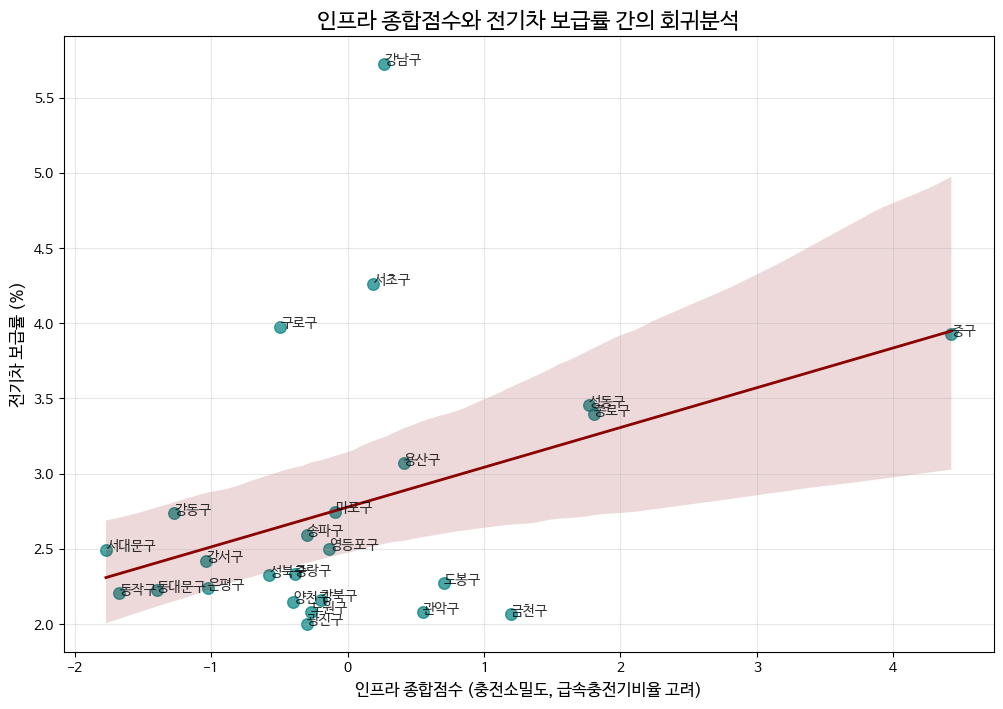

In [61]:
# 3. 회귀분석 및 산점도 시각화
plt.figure(figsize=(12, 8))

# 산점도 + 회귀선 시각화
sns.regplot(
    data=df_final,
    x='인프라종합점수',
    y='전기차보급률(%)',
    scatter_kws={'alpha': 0.7, 's': 70, 'color': 'teal'},
    line_kws={'color': 'darkred', 'lw': 2}
)

# 데이터 포인트에 자치구 이름 표시
for i, row in df_final.iterrows():
    plt.text(
        row['인프라종합점수'],
        row['전기차보급률(%)'],
        row['자치구'],
        fontsize=10,
        alpha=0.8
    )

plt.title('인프라 종합점수와 전기차 보급률 간의 회귀분석', fontsize=16)
plt.xlabel('인프라 종합점수 (충전소밀도, 급속충전기비율 고려)', fontsize=12)
plt.ylabel('전기차 보급률 (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()



In [65]:
# 4. 분석 결과 (상관분석 & 회귀계수)
# 피어슨 상관분석
pearson_corr, pearson_p = pearsonr(df_final['인프라종합점수'], df_final['전기차보급률'])

print('\n[인프라 종합점수 - 전기차 보급률 분석 결과]')
print(f'피어슨 상관계수: {pearson_corr:.4f} (p-value: {pearson_p:.4f})')

if pearson_p < 0.05:
    print('💡 인프라 종합점수와 전기차 보급률 사이에 통계적으로 유의한 상관관계가 존재합니다.')
else:
    print('💡 통계적으로 유의한 상관관계가 있다고 보기 어렵습니다.')

#스피어만 상관분석
from scipy.stats import spearmanr

# 스피어만 상관분석
spearman_corr, spearman_p = spearmanr(
    df_final['인프라종합점수'],
    df_final['전기차보급률(%)']
)

print('\n[스피어만 상관분석]')
print(f'스피어만 상관계수: {spearman_corr:.4f} (p-value: {spearman_p:.4f})')

if spearman_p < 0.05:
    print('💡 인프라 종합점수와 전기차 보급률 사이에 통계적으로 유의한 상관관계가 존재합니다.')
else:
    print('💡 통계적으로 유의한 상관관계가 있다고 보기 어렵습니다.')


# 선형 회귀 모형 적합
X = df_final[['인프라종합점수']]
y = df_final['전기차보급률(%)']
model = LinearRegression()
model.fit(X, y)

print(f'\n[회귀모델 정보]')
print(f'회귀계수(기울기): {model.coef_[0]:.4f}')
print(f'R-squared(설명력): {model.score(X, y):.4f}')


[인프라 종합점수 - 전기차 보급률 분석 결과]
피어슨 상관계수: 0.3866 (p-value: 0.0562)
💡 통계적으로 유의한 상관관계가 있다고 보기 어렵습니다.

[스피어만 상관분석]
스피어만 상관계수: 0.2600 (p-value: 0.2094)
💡 통계적으로 유의한 상관관계가 있다고 보기 어렵습니다.

[회귀모델 정보]
회귀계수(기울기): 0.2644
R-squared(설명력): 0.1495


# 강남구 제외 (인프라종합점수)

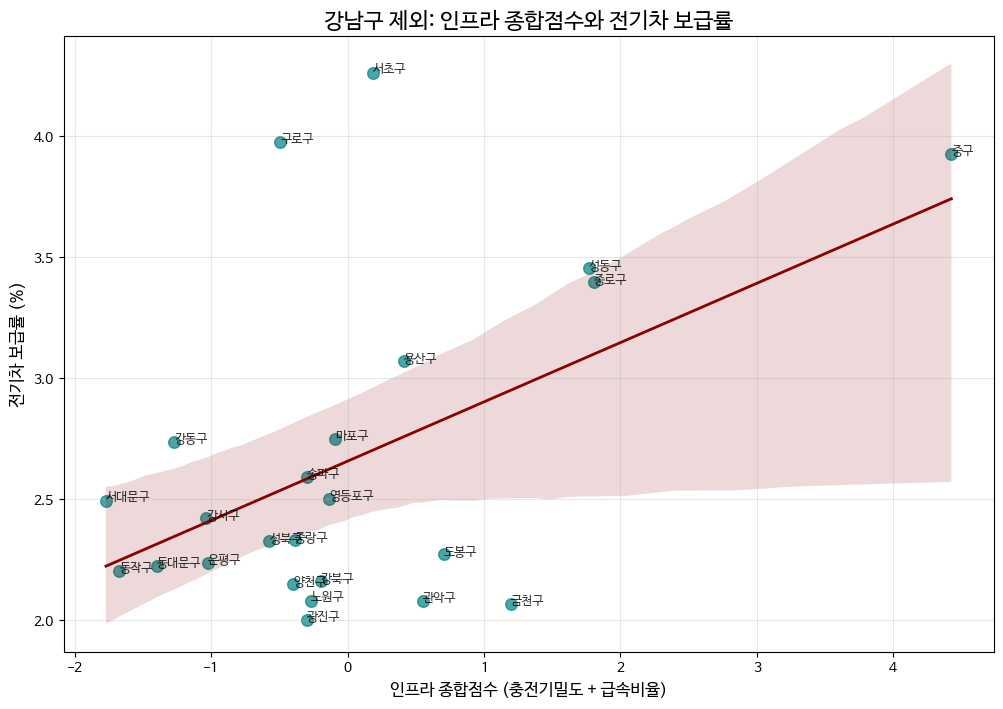

In [68]:
df_no_gangnam = df_final[df_final['자치구'] != '강남구']

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.regplot(
    data=df_no_gangnam,
    x='인프라종합점수',
    y='전기차보급률(%)',
    scatter_kws={'alpha': 0.7, 's': 70, 'color': 'teal'},
    line_kws={'color': 'darkred', 'lw': 2}
)

# 자치구 라벨 표시
for i, row in df_no_gangnam.iterrows():
    plt.text(
        row['인프라종합점수'],
        row['전기차보급률(%)'],
        row['자치구'],
        fontsize=9,
        alpha=0.8
    )

plt.title('강남구 제외: 인프라 종합점수와 전기차 보급률', fontsize=16)
plt.xlabel('인프라 종합점수 (충전기밀도 + 급속비율)', fontsize=12)
plt.ylabel('전기차 보급률 (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [70]:
from sklearn.linear_model import LinearRegression

# 전체 데이터
X_all = df_final[['인프라종합점수']]
y_all = df_final['전기차보급률(%)']

model_all = LinearRegression()
model_all.fit(X_all, y_all)

# 강남구 제외 데이터
X_no = df_no_gangnam[['인프라종합점수']]
y_no = df_no_gangnam['전기차보급률(%)']

model_no = LinearRegression()
model_no.fit(X_no, y_no)

print('[R² 비교]')
print(f'전체 데이터 R²: {model_all.score(X_all, y_all):.4f}')
print(f'강남구 제외 R²: {model_no.score(X_no, y_no):.4f}')

[R² 비교]
전체 데이터 R²: 0.1495
강남구 제외 R²: 0.2406
